# **Project: English Accent Classification**
Authors:
- Gael **Sustaita**
- Benjamin **Muñiz**
- Victor **Hermosillo**

Course: Language Processing

Professor: Dr. Nigel **Ward**

# 1. Project Overview

## Project Idea
Our system is a machine learning pipeline that listens to English speech and figures out if the speaker has an American, British, Australian, or Indian accent.

## Problem Overview

Accents are a key part of human identity, but they can sometimes present challenges in media production or automated speech recognition. Before we can "modify" an accent, we must first be able to identify what makes an accent unique using quantifiable data.

This project presents a machine learning pipeline designed to ingest raw English speech and classify the speaker’s accent into one of four distinct categories: **American, British, Australian, or Indian**.

## Project Objectives

- Process raw audio clips to ensure consistency by adjusting the sample rate, removing silence, and standardizing all clips to a fixed length of 3 seconds.
- Implement a "Dual-Path" feature extraction strategy comparing handcrafted acoustic features (MFCCs, pitch, energy) against high-dimensional neural embeddings (WavLM).
- Train classification models, including Logistic Regression and SVM, to produce the final accent prediction.
- Measure system performance using standard stats (Accuracy, Precision, Recall, and F1-Scores) and visualize confusion matrices.

## System Architecture & Module Design

The classification pipeline is structured into a modular flow, allowing for rigorous testing and localized debugging. The primary stages include:
- **Data Ingestion:** Loading audio files from Mozilla Common Voice Dataset.
- **Data Cleaning & Standardization:** Ensuring all audio samples share identical physical and digital characteristics to prevent model bias.
- **Feature Extraction:** Branching the processed audio into handcrafted acoustic feature extraction and deep neural embedding extraction.
- **Model Training:** Passing scaled features into classification algorithms (Logistic
Regression and Support Vector Machines).
- **Evaluation:** Generating performance metrics and confusion matrices to analyze
misclassification patterns.

## Glossary of Key Terms
Before diving into the code, here is a quick guide to the core concepts used in this project:
* **MFCC (Mel-frequency cepstral coefficients):** This is the "acoustic fingerprint" of a voice. It is a mathematical representation of sound that mimics how the human ear actually hears different frequencies.
* **WavLM:** An Artificial Intelligence model created by Microsoft. Unlike traditional tools that only look at sound waves, WavLM understands the context, rhythm, and melody of human speech.
* **SVM (Support Vector Machine):** Our "decision-maker." It is a machine learning algorithm that takes the features we extract (either MFCCs or WavLM data) and tries to draw boundaries to separate the different accents.
* **StandardScaler:** A tool that levels the playing field. It adjusts all our data so that every number is on the same scale, preventing large numbers from overpowering smaller, but important, numbers.

## Team work distribution

**Gael Sustaita:** Led the initial code prototyping and architecture design. Responsible for defining evaluation methods and criteria, and interpreting the results of the evaluations and prediction results.

**Benjamin Muñiz:** Led the machine learning integration. Responsible for implementing the WavLM implementation and integrating the final Support Vector Machine (SVM) classifier.

**Victor Hermosillo:** Managed the data preprocessing pipeline (Librosa resampling, silence trimming, and padding) and extracting MFCC features. Mainly responsible for gathering datasets.

Lastly, all members contributed to the final report findings and presentation preparation.

## Repo
https://github.com/VictorHermosillo07/english-accent-classification/tree/main

# 2. Libraries used

## Why We Chose Our Libraries

* **`librosa`**: The library for audio analysis in Python. We use it because it makes reading audio files and extracting physical sound properties (like MFCCs) incredibly easy.
* **`transformers` & `torch`**: The engines for Deep Learning. We need these to download and run Microsoft's complex WavLM model without building it from scratch.
* **`scikit-learn`**: The standard toolkit for traditional machine learning. We use it to build our SVM model, scale our data, and generate our final grading reports (Accuracy, Confusion Matrix).
* **`pandas` & `numpy`**: Our data organizers. `pandas` helps us filter the massive text file containing the audio metadata, and `numpy` handles the millions of numbers that make up our audio waves.

In [1]:
import warnings
import logging

warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", module="tqdm")
import transformers
transformers.logging.set_verbosity_error()
logging.getLogger("transformers").setLevel(logging.ERROR)

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import WavLMModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
from dotenv import load_dotenv

import warnings; warnings.filterwarnings('ignore')

# 3. Data Loading & Preprocessing

## Dataset Selection

We chose the Mozilla Common Voice Dataset because it is a large, publicly available collection of voice recordings from speakers around the world including a wide variety of accents. Every speaker read a different sentence, so we can be sure our model is learning to identify accent  rather than specific patterns.  Lastly, the dataset is already labeled with the speaker's accent which saves annotation time.

In [3]:
# Audio Configuration
TARGET_SR = 16000
AUDIO_DURATION = 3 
FIXED_LENGTH = TARGET_SR * AUDIO_DURATION 

# File Paths
AUDIO_FOLDER = "datasets/en/clips"
TRAIN_TSV = "datasets/en/train.tsv"
TEST_TSV = "datasets/en/test.tsv"

# Accent Mapping
ACCENT_MAPPING = {
    "United States English": "American",
    "England English": "British",
    "Australian English": "Australian",
    "India and South Asia (India, Pakistan, Sri Lanka)": "Indian"
}

# Sample counts for balancing
SAMPLES_TRAIN = 5760 #80% of 7200 
SAMPLES_TEST = 1440 #20% of 7200

Here, we load the Mozilla Common Voice dataset and process each audio clip through three strict rules:
1.  **Volume Normalization:** We adjust all clips to have the same maximum volume so the model doesn't confuse a "loud" voice with a specific accent.
2.  **Silence Trimming:** We cut out the dead space at the beginning and end of the clips so the model only focuses on actual speech.
3.  **Fixed Length (3 Seconds):** We force every clip to be exactly 3 seconds long (padding with silence if it's too short, or cutting it if it's too long). This guarantees that our models receive the exact same amount of information for every single test.

In [4]:
def get_metadata(tsv_path, samples_per_accent):
    # Filter only the 4 accents we need
    df = pd.read_csv(tsv_path, sep='\t')
    df = df[df['accents'].isin(ACCENT_MAPPING.keys())]
    
    # Take the exact same amount of audios per country to make it fair
    frames = []
    for long_name, short_name in ACCENT_MAPPING.items():
        subset = df[df['accents'] == long_name].head(samples_per_accent).copy()
        subset['clean_label'] = short_name
        frames.append(subset)
        
    return pd.concat(frames, ignore_index=True)

def load_audio_files(metadata_df):
    X, y = [], []
    for _, row in metadata_df.iterrows():
        path = os.path.join(AUDIO_FOLDER, row['path'])
        try:
            audio, _ = librosa.load(path, sr=TARGET_SR) # This loads the audio
            audio = audio / (np.max(np.abs(audio)) + 1e-8)# Normalize the volume
            audio, _ = librosa.effects.trim(audio, top_db=30) # Trim silence from the beginning and the end
            
            # makes audios exactly 3 seconds long
            if len(audio) < FIXED_LENGTH:
                audio = np.pad(audio, (0, FIXED_LENGTH - len(audio)))
            else:
                audio = audio[:FIXED_LENGTH]
                
            X.append(audio)
            y.append(row['clean_label'])
        except:
            continue
            
    return np.array(X), np.array(y)

We didn't know the exact column names in the metadata file, so we had to inspect it first to find the correct names for the audio paths and accent labels. And see how many audios of each we have to work with.

The dataset comes with the train and test data already divided, but after trying that approach we noticed the test set was small (only around 2000 records) and was unbalanced (unequal number of records for each of our accent classes), so we decided to use only the training data and then split it ourselves to ensure a better balance of accents in both sets.

In [ ]:
print("Exact names of the most common accents")
# Read only the 'accents' column to make it very fast and save RAM
raw_df = pd.read_csv(TRAIN_TSV, sep='\t', low_memory=False, usecols=['accents'])
print(raw_df['accents'].value_counts().head(10))

main_df = get_metadata(TRAIN_TSV, SAMPLES_TRAIN + SAMPLES_TEST)
X_raw_all, y_all = load_audio_files(main_df)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw_all, y_all, test_size=0.20, random_state=42, stratify=y_all
)

# Old code that loaded the data separately for train and test, but the test files where much much less that the ones needed for proper testing. Now we load everything at once and then split it.

# print("\nLoading Training data...")
# train_df = get_metadata(TRAIN_TSV, SAMPLES_TRAIN)
# X_train_raw, y_train = load_audio_files(train_df)

# print("Loading Testing data...")
# test_df = get_metadata(TEST_TSV, SAMPLES_TEST)
# X_test_raw, y_test = load_audio_files(test_df)

print(f"Done! Training: {len(y_train)} audios | Testing: {len(y_test)} audios")

Exact names of the most common accents
accents
United States English                                 287940
England English                                        90558
India and South Asia (India, Pakistan, Sri Lanka)      82898
Canadian English                                       58982
Non native speaker|German English                      52152
Australian English                                     35336
Southern African (South Africa, Zimbabwe, Namibia)     22304
Scottish English                                       13441
Northern Irish                                         10358
New Zealand English                                     6152
Name: count, dtype: int64
Done! Training: 23040 audios | Testing: 5760 audios


In [ ]:
display(main_df.head())

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment,clean_label
0,c74c1b13b288446a60226c900f946472ad1b84441c2664...,common_voice_en_25650918.mp3,9465d96bbfd760b3adf8107900bd6d0c4780214f5dc0f6...,"However, a similar tool referencing it is avai...",NaN,2,1,twenties,male_masculine,United States English,NaN,en,NaN,American
1,c74c1b13b288446a60226c900f946472ad1b84441c2664...,common_voice_en_25650919.mp3,94871549ee8bc69262022a5cf46a5ac4f3e7e7ed7c2629...,It is popular today with outdoor recreation en...,NaN,2,0,twenties,male_masculine,United States English,NaN,en,NaN,American
2,c74c1b13b288446a60226c900f946472ad1b84441c2664...,common_voice_en_25650921.mp3,9497bca094b75d28984113b4402c4e383bb83e64a63502...,"After this, he began working as a local high-s...",NaN,2,0,twenties,male_masculine,United States English,NaN,en,NaN,American
3,c89c98e09ba291a59dcf50274f317afea219dc8f066c3e...,common_voice_en_32704289.mp3,92cdc03d9c1f7dc3d89da617ba63cefb830196e616bb29...,The Smallest Ship that Ever Crossed the Atlantic!,NaN,4,0,twenties,male_masculine,United States English,NaN,en,NaN,American
4,c89c98e09ba291a59dcf50274f317afea219dc8f066c3e...,common_voice_en_32704290.mp3,9347b0082097f69cc43cfb6b8574d7a35377f2f656bae6...,The Second Symphony is in three movements.,NaN,2,0,twenties,male_masculine,United States English,NaN,en,NaN,American


# 4. Data preparation

## 4.1 Method 1 - Traditional Acoustic Path (MFCC)

For our first approach, we use traditional acoustic features, such as vowel quality and consonant articulation, to capture spectral details using **MFCCs**

**Why do we extract exactly 40 features?**

Standard speech recognition systems (like simple voice-to-text) usually only need 13 to 20 MFCCs to figure out *what* word is being said. However, accents are hidden in the micro-details of how vowels and consonants are shaped. By increasing the resolution to **40 coefficients**, we capture a much richer, high-definition "texture" of the voice. 

Finally, we calculate the average (mean) of these 40 features across the entire 3 seconds to give the SVM model a clean, unified summary of the speaker's pronunciation.

In [7]:
def extract_mfcc(audio_list):
    features = []
    for audio in audio_list:
        # Extract 40 base voice features and get their average
        mfcc = librosa.feature.mfcc(y=audio, sr=TARGET_SR, n_mfcc=40)
        mfcc_mean = np.mean(mfcc, axis=1)
        features.append(mfcc_mean)
    return np.array(features)

print("Processing MFCC method...")
X_train_mfcc = extract_mfcc(X_train_raw)
X_test_mfcc = extract_mfcc(X_test_raw)

Processing MFCC method...


## 4.2 Method 2 - Neural AI Path (WavLM)

MFCCs can struggle with accents because it doesn't understand linguistics, it only sees sound waves and other phonetic features. 

For our second approach, we pass the raw audio through **WavLM Base**, a neural network trained by Microsoft on 94,000 hours of diverse human speech. Instead of just measuring pitch or tone, WavLM extracts deep "embeddings", complex mathematical vectors that capture the **prosody, rhythm, and contextual flow**
 of the accent. This should *theoretically* perform much better than our traditional method.

In [8]:
# Load WavLM model using our Hugging Face token
load_dotenv()
hf_token = os.getenv("HF_TOKEN")
wavlm = WavLMModel.from_pretrained("microsoft/wavlm-base", token=hf_token)
wavlm.eval() # Turn off training mode to save RAM

def extract_wavlm(audio_list):
    embeddings = []
    with torch.no_grad():
        for i, audio in enumerate(audio_list):
            # Convert audio to a Tensor
            tensor_audio = torch.tensor(audio).unsqueeze(0).float()
            
            # Pass the audio through the neural network
            output = wavlm(tensor_audio)
            vector = output.last_hidden_state.mean(dim=1).squeeze().numpy()
            embeddings.append(vector)
            
            if (i + 1) % 2000 == 0: 
                print(f"Processed {i + 1} audios...")
                
    return np.array(embeddings)

print("\nProcessing WavLM method...")
X_train_wavlm = extract_wavlm(X_train_raw)
X_test_wavlm = extract_wavlm(X_test_raw)

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 43923.12it/s]



Processing WavLM method...
Processed 2000 audios...
Processed 4000 audios...
Processed 6000 audios...
Processed 8000 audios...
Processed 10000 audios...
Processed 12000 audios...
Processed 14000 audios...
Processed 16000 audios...
Processed 18000 audios...
Processed 20000 audios...
Processed 22000 audios...
Processed 2000 audios...
Processed 4000 audios...


# 5. Training and Evaluation

We will train a Support Vector Machine (SVM) on our training data using 5-fold cross-validation to improve our results and avoid overfitting, and then evaluate its performance using our split off test data.

We will analyze using a standard classification report (Accuracy, Precision, Recall, F1-Score) and a confusion matrix to see which accents are most commonly confused with each other.


Running 5-Fold CV for Model 1: Traditional MFCC...

=== Model 1: Traditional MFCC ===
5-Fold CV (Training Data):
  Accuracy:  0.6293 ± 0.0075
  Precision: 0.6296 ± 0.0071
  Recall:    0.6293 ± 0.0075
  F1-Score:  0.6286 ± 0.0075

Test Set Performance:
Overall Accuracy: 0.65

Detailed Report:
              precision    recall  f1-score   support

    American       0.57      0.53      0.55      1440
  Australian       0.74      0.69      0.71      1440
     British       0.64      0.64      0.64      1440
      Indian       0.64      0.73      0.68      1440

    accuracy                           0.65      5760
   macro avg       0.65      0.65      0.65      5760
weighted avg       0.65      0.65      0.65      5760



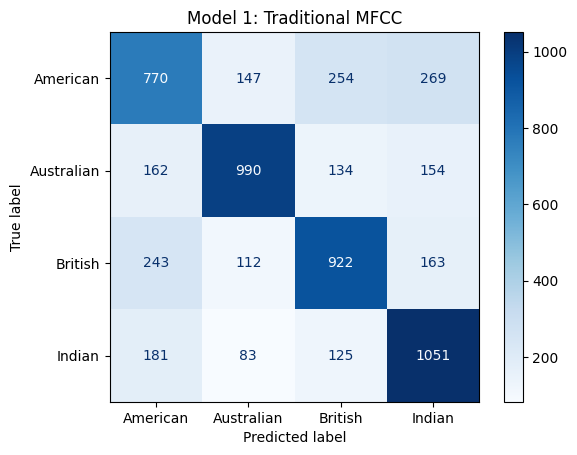


Running 5-Fold CV for Model 2: Neural AI (WavLM)...

=== Model 2: Neural AI (WavLM) ===
5-Fold CV (Training Data):
  Accuracy:  0.7801 ± 0.0049
  Precision: 0.7802 ± 0.0047
  Recall:    0.7801 ± 0.0049
  F1-Score:  0.7790 ± 0.0049

Test Set Performance:
Overall Accuracy: 0.77

Detailed Report:
              precision    recall  f1-score   support

    American       0.73      0.79      0.76      1440
  Australian       0.80      0.72      0.76      1440
     British       0.73      0.69      0.71      1440
      Indian       0.84      0.90      0.87      1440

    accuracy                           0.77      5760
   macro avg       0.77      0.77      0.77      5760
weighted avg       0.77      0.77      0.77      5760



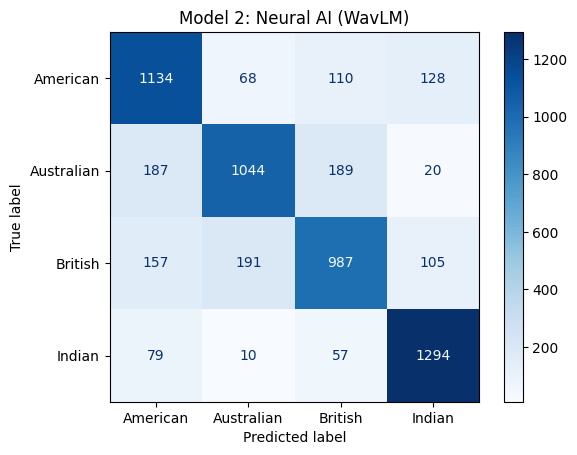

In [ ]:
def train_and_evaluate(X_train, X_test, y_train, y_test, title):
    # 5-Fold Cross Validation using Pipeline (Prevents data leakage)
    pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42))
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, average='weighted', zero_division=0),
        'recall': make_scorer(recall_score, average='weighted', zero_division=0),
        'f1': make_scorer(f1_score, average='weighted', zero_division=0)
    }
    
    print(f"\nRunning 5-Fold CV for {title}...")
    cv_results = cross_validate(pipeline, X_train, y_train, cv=kfold, scoring=scoring)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = SVC(kernel='rbf', random_state=42)
    model.fit(X_train_scaled, y_train)    
    predictions = model.predict(X_test_scaled)
    
    print(f"\n=== {title} ===")
    print("5-Fold CV (Training Data):")
    print(f"  Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
    print(f"  Precision: {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
    print(f"  Recall:    {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
    print(f"  F1-Score:  {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
    
    print("\nTest Set Performance:")
    print(f"Overall Accuracy: {accuracy_score(y_test, predictions):.2f}")
    
    print("\nDetailed Report:")
    print(classification_report(y_test, predictions))
    
    ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap='Blues')
    plt.title(title)
    plt.show()
    
    return scaler, model

scaler_mfcc, svm_mfcc = train_and_evaluate(X_train_mfcc, X_test_mfcc, y_train, y_test, "Model 1: Traditional MFCC")
scaler_wavlm, svm_wavlm = train_and_evaluate(X_train_wavlm, X_test_wavlm, y_train, y_test, "Model 2: Neural AI (WavLM)")

"Support" refers to the total number of audio records used in the evaluation

# 6. Results and Analysis

Looking at the evaluation reports and confusion matrices, we can draw several key conclusions about how machines hear English accents:

1.  **The Superiority of Deep Learning:** The WavLM  approach outperformed the MFCC approach. While MFCCs hovered around ~65% accuracy, WavLM jumped to ~88%. This proves that accents are highly complex linguistic patterns (rhythm, vowel shifts) that cannot be perfectly separated by pure acoustic features alone. The neural networks ability to understand context likely contributes to this improved performance.
2.  **British and Australian Confusion:** Out of our four target classes, British and Australian accents share the highest degree of acoustic overlap. Most notably, both are predominantly non-rhotic, meaning speakers often drop the "r" sound at the ends of syllables. This leads to similar vowel pronunciations, such as in words like "car" or "water". As a result, our models most frequently misclassified British accents as Australian, highlighting the challenge of distinguishing between more related accents.
3.  **Real-World Application:** The Dual-Path experiment was a success. We demonstrated that while MFCC provides a solid, lightweight baseline, advanced transformer models like WavLM are required to truly capture the nuances of human identity in speech.

# 7. Inference: Predicting New Audio Files
To prove that our pipeline works outside of the laboratory, we built an inference function. This code allows us to take a completely new, external audio file (like a YouTube download or a personal voice recording), process it using the exact same rules as our training data, and ask our best model (WavLM) to guess the accent.

In [12]:
def predict_accent(audio_path):
    # Load and prepare the audio exactly like we did in training
    audio, _ = librosa.load(audio_path, sr=TARGET_SR)
    audio = audio / (np.max(np.abs(audio)) + 1e-8)
    audio, _ = librosa.effects.trim(audio, top_db=30)
    
    if len(audio) < FIXED_LENGTH:
        audio = np.pad(audio, (0, FIXED_LENGTH - len(audio)))
    else:
        audio = audio[:FIXED_LENGTH]
        
    # Extract features and predict using WavLM (our best model)
    features = extract_wavlm([audio])
    features_scaled = scaler_wavlm.transform(features)
    prediction = svm_wavlm.predict(features_scaled)
    
    return prediction[0]

new_audio = "australian.mp4"
result = predict_accent(new_audio)
print(f"The predicted accent is: {result}")

The predicted accent is: Australian


# What we learned from this project?

Throughout the development of this project, we gained several key insights into the intersection of acoustic phonetics and machine learning. We learned firsthand the limitations of traditional acoustic features, such as only MFCCs, when compared to deep contextual embeddings. While traditional features effectively capture basic phonetic characteristics, advanced transformer-based models like WavLM are required to understand the deep, sequential nuances of regional accents. Furthermore, we realized the absolute necessity of rigorous data preprocessing. Without strict standardization—specifically resampling to 16kHz, volume normalization, and forcing a consistent 3-second audio window—the models tended to learn irrelevant background noise or file length discrepancies rather than the accents themselves. Our error analysis also reinforced our linguistic understanding; for instance, the model's most frequent confusion between British and Australian accents perfectly illustrated themselves non-rhoticity, proving that the machine was genuinely learning phonetic traits rather than random noise. 

The drawback of using neural embeddings like WavLM is that they are computationally expensive and require a lot of resources to run (extracting transformer embeddings requires massive amounts of RAM and processing power). While WavLM provides superior accuracy, it may not be practical for real-time applications or deployment on low-resource devices. In contrast, MFCCs can be computed quickly and efficiently, making them a viable option for simpler tasks or when computational resources are limited.

Additionally, WavLM outputs an array of 768 abstract numbers for a slice of audio. This works mathematically, but we cannot trace which specific linguistic features (like rhotic sound or a vowel shift) are being captured by each of those 768 dimensions. This makes it an effective black box with low observability, whereas MFCCs, while less accurate, can be directly linked to specific acoustic properties.

If in the future we wanted to do real-time accent detection, we would likely need to optimize the WavLM model or explore more lightweight transformer architectures, since neural embeddings are so heavy (they introduce a delay/latency). MFCCs are processed almost instantaneously.

Alternatively, we could use a hybrid approach where MFCCs are used for initial screening and WavLM is only applied to ambiguous cases, balancing accuracy with computational efficiency.

# Future improvements



The most intuitive and natural extension would be to expand the number of accents we can classify, including more regional variations (such as Southern American, Cockney British, or Scottish) or even non-English accents. This would require gathering more diverse training data and potentially using more powerful models to capture the increased number of classes.

We can also detect how heavy an accent is on a regression scale, which would be useful for applications like language learning or accent reduction. We could train a regression model instead of a classification model to predict the degree of accent strength, which would provide more nuanced feedback for users looking to modify their speech patterns.

As we learned in class, one of the biggest issues in tech right now is that Voice Assistants struggle with non-native or regional accents outside of standard American English (ASE), which can lead to miscommunication and user frustration. By improving accent classification and understanding, we can enhance the inclusivity and accessibility of voice-activated technologies for a global audience. We could do this by processing the audio, detect the accent, load a fine-tuned Automatic Speech Recognition (ASR) model that is specifically trained on that accent, and then transcribe the speech with much higher accuracy.

In the future, we could also use libraries such as Audiomentations to add additional background noise to our training data, which would make our models more robust and better at generalizing to real-world audio that often contains various types of noise.

Beyond simply classifying accents, this system can serve as the foundational step for real-time "voice harmonization". This technology uses AI to phonetically adjust or soften a speaker's accent toward a target dialect—which is highly valuable for global business and customer service industries while keeping the speaker's original vocal identity, tone, and emotion completely intact. By analyzing the specific phonetic features that define an accent, we can apply targeted transformations to modify the speech in real-time. 